In [70]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
from astropy.constants import m_e, e ,c 
from astropy import units as u
from scipy.constants import physical_constants
from scipy.constants import physical_constants, c as cc
from scipy import special

In [90]:
C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952

nu_K = cc / C_IV_K
nu_H = cc / C_IV_H


voigt_path = r'/home/jin/Addition_RT/RT_main/CIV_Voigt_data/CIV_Voigt_30.txt'
# voigt_path = r'/home/jin/RT/RT_main/CIV_Voigt_data/Mg_II.txt'
name = ['lambda','sigma']
voigt_file = pd.read_csv(voigt_path,sep='\s+',names=name,)

lam, scat = voigt_file['lambda'].to_numpy() , voigt_file['sigma'].to_numpy()

Mg_II_K = 2795.528e-8 
Mg_II_H = 2802.705e-8

del_V =  ((lam-C_IV_K) / C_IV_K) * cc /1e5 # km/s
V_c = 250 # km/s
Vsep = abs(( C_IV_H - C_IV_K) / C_IV_K)*cc_k
Vsep
# 

500.56195015845793

Text(0, 0.5, '$\\sigma_{\\rm scat} ~ [\\rm cm^{2}]$')

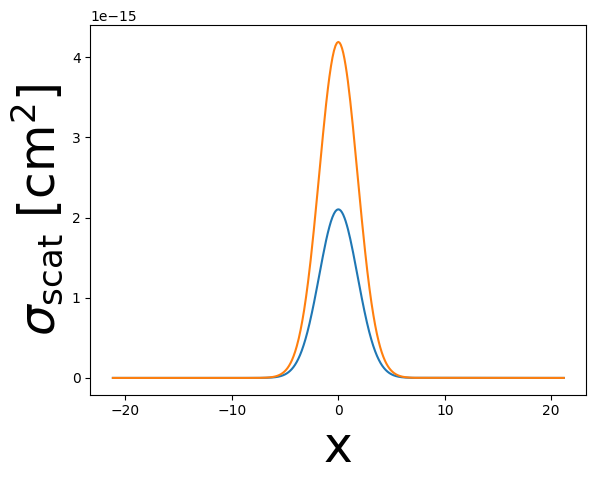

In [91]:
K_region = np.where((del_V >= -V_c) & (del_V <= V_c))
H_region = np.where((del_V >= Vsep-V_c) & (del_V <= Vsep + V_c))

delV_K,cs_K = del_V[K_region], scat[K_region]
delV_H, cs_H  = del_V[H_region], scat[H_region]

x_K = delV_K / (-11.8) 
x_H = (delV_H-Vsep) / (-11.8) 

plt.plot(x_H,cs_H)
plt.plot(x_K,cs_K)

plt.xlabel('x',fontsize=35)
plt.ylabel(r'$\sigma_{\rm scat} ~ [\rm cm^{2}]$', fontsize=35)

[1.5128138410707586, -1.515116542239198]
0.0 0.998932974


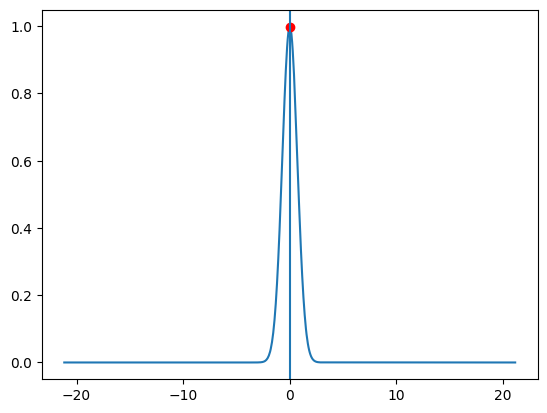

In [113]:
# C_iv_N = np.linspace(1e12, 5e16, int(NN))
C_iv_N = np.array([2.67e13])

v_th = 11.8

voigt_path = r'/home/jin/Addition_RT/RT_main/CIV_Voigt_data/CIV_Voigt_11_8.txt'




name = ['lambda','sigma']
voigt_file = pd.read_csv(voigt_path,sep='\s+',names=name,)

lam, scat = voigt_file['lambda'].to_numpy() , voigt_file['sigma'].to_numpy()

del_V =  ((lam-C_IV_K) / C_IV_K) * cc /1e5 # km/s Change from lam to velocity space (K line standard)
V_c = 250 # km/s ()
Vsep = abs(( C_IV_H - C_IV_K) / C_IV_K)*cc_k


K_region = np.where((del_V >= -V_c) & (del_V <= V_c))
H_region = np.where((del_V >= Vsep-V_c) & (del_V <= Vsep + V_c))

delV_K,cs_K = del_V[K_region], scat[K_region]
delV_H, cs_H  = del_V[H_region], scat[H_region]

x_K = delV_K / (-v_th) 
x_H = (delV_H-Vsep) / (-v_th) 

tau_profile_K = C_iv_N[:, None] * cs_K
x_esc = np.zeros(len(C_iv_N))
for ii in range(len(C_iv_N)):
    tau_i = tau_profile_K[ii, :]
    s = tau_i - 1.0

    # Find sign changes of (tau - 1) and linearly interpolate x where tau=1
    cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

    if cross_idx.size == 0:
        x_esc[ii] = 0.0
        continue

    x_candidates = []
    for jj in cross_idx:
        tau_a, tau_b = tau_i[jj], tau_i[jj + 1]
        x_a, x_b = x_K[jj], x_K[jj + 1]

        if tau_b == tau_a:
            continue

        x_cross = x_a + (1.0 - tau_a) * (x_b - x_a) / (tau_b - tau_a)
        x_candidates.append(x_cross)

    # Keep the maximum x (matches original idea of choosing the positive boundary)
    x_esc[ii] = max(x_candidates) if len(x_candidates) > 0 else 0.0

del_lam_D = (v_th*1e5) / C_IV_K
nu_0_K= cc/C_IV_K
nu_esc =x_esc*del_lam_D + nu_0_K
V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
v_esc = x_esc*v_th
N_esc= 1/special.erfc(v_esc/v_th)

print(x_candidates)
plt.plot(x_K,tau_profile_K[0,:])

# plt.plot(x_K[x_candidates[0]],,'ro')
# plt.plot(x_K[x_p[1]],tau_profile_K[0,x_p[1]],'ro')

idx = np.argsort(x_K)
x_sorted = x_K[idx]
tau_sorted = tau_profile_K[0][idx]

y_esc = np.interp(x_esc[0], x_sorted, tau_sorted)
print(x_esc[0], y_esc)
plt.plot(x_esc[0], y_esc, 'ro')

# plt.plot(x_esc[0],tau_profile_K[0,ii],'ro')
plt.axvline(x_esc[0],ymin=0,ymax=1)





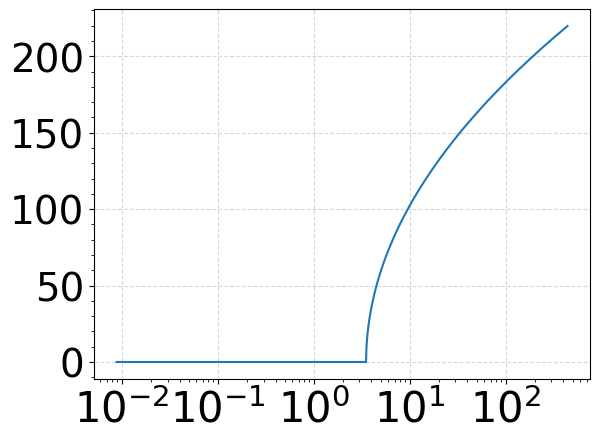

In [93]:
rr = np.arange(12, 18, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()

# tau_K = 2.67e13 * cs_K
# plt.plot(x_K,tau_K)

NN = 5e3
v_th = 50

C_iv_N = np.logspace(np.log10(1e12), np.log10(5e16), int(NN))

def N_esc_scat(v_th):

    if v_th == 11.8:
        voigt_path = r'/home/jin/Addition_RT/RT_main/CIV_Voigt_data/CIV_Voigt_11_8.txt'
    elif v_th == 30:
        voigt_path = r'/home/jin/Addition_RT/RT_main/CIV_Voigt_data/CIV_Voigt_30.txt'
    elif v_th == 50:
        voigt_path = r'/home/jin/Addition_RT/RT_main/CIV_Voigt_data/CIV_Voigt_50.txt'
    else:
        print("We do not have the Voigt profile for the random motion")
        return None

   
    name = ['lambda','sigma']
    voigt_file = pd.read_csv(voigt_path,sep='\s+',names=name,)

    lam, scat = voigt_file['lambda'].to_numpy() , voigt_file['sigma'].to_numpy()

    del_V =  ((lam-C_IV_K) / C_IV_K) * cc /1e5 # km/s Change from lam to velocity space (K line standard)
    V_c = 250 # km/s ()
    Vsep = abs(( C_IV_H - C_IV_K) / C_IV_K)*cc_k


    K_region = np.where((del_V >= -V_c) & (del_V <= V_c))
    H_region = np.where((del_V >= Vsep-V_c) & (del_V <= Vsep + V_c))

    delV_K,cs_K = del_V[K_region], scat[K_region]
    delV_H, cs_H  = del_V[H_region], scat[H_region]

    x_K = delV_K / (-v_th) 
    x_H = (delV_H-Vsep) / (-v_th) 

    tau_profile_K = C_iv_N[:, None] * cs_K

    x_0 = np.zeros(len(C_iv_N))
    for ii in range(len(C_iv_N)):
        tau_i = tau_profile_K[ii, :]
        s = tau_i - 1.0

        # Find sign changes of (tau - 1) and linearly interpolate x where tau=1
        cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

        if cross_idx.size == 0:
            x_0[ii] = 0.0
            continue

        x_candidates = []
        for jj in cross_idx:
            tau_a, tau_b = tau_i[jj], tau_i[jj + 1]
            x_a, x_b = x_K[jj], x_K[jj + 1]

            if tau_b == tau_a:
                continue

            x_cross = x_a + (1.0 - tau_a) * (x_b - x_a) / (tau_b - tau_a)
            x_candidates.append(x_cross)

        # Keep the maximum x (matches original idea of choosing the positive boundary)
        x_0[ii] = max(x_candidates) if len(x_candidates) > 0 else 0.0

    del_lam_D = (v_th*1e5) / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_0*del_lam_D + nu_0_K
    V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    v_esc = x_0*v_th
    N_esc= 1/special.erfc(v_esc/v_th)
    
    return  V_del_peak




def tau_k(Nciv,Vrand):
    tau_0 = (Nciv/2.67e13)*(11.8/Vrand)
    return tau_0

    
tt = N_esc_scat(v_th)

C_iv_N = np.logspace(np.log10(1e12), np.log10(5e16), int(NN))
tauk =tau_k(C_iv_N,v_th)






plt.plot(tauk,tt)
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel(r'${N} \, _{\mathrm{C IV}}$ [cm$^{-2}$]',fontsize =35)
plt.xscale('log')
# plt.yscale('log')
# plt.xlim(2*10**12,3*10**16)
plt.xticks(fontsize=30)
plt.yticks(fontsize=28)

# plt.ylabel(r'Number of Scattering',fontsize =32)
plt.minorticks_on()
plt.grid(True,linestyle='--',alpha=0.5)

In [75]:
def N_esc_scat(v_th):

    if v_th == 11.8:
        voigt_path = r'/home/jin/Addition_RT/RT_main/CIV_Voigt_data/CIV_Voigt_11_8.txt'
    elif v_th == 30:
        voigt_path = r'/home/jin/Addition_RT/RT_main/CIV_Voigt_data/CIV_Voigt_30.txt'
    elif v_th == 50:
        voigt_path = r'/home/jin/Addition_RT/RT_main/CIV_Voigt_data/CIV_Voigt_50.txt'
    else:
        print("We do not have the Voigt profile for the random motion")
        return None

   
    name = ['lambda','sigma']
    voigt_file = pd.read_csv(voigt_path,sep='\s+',names=name,)

    lam, scat = voigt_file['lambda'].to_numpy() , voigt_file['sigma'].to_numpy()

    del_V =  ((lam-C_IV_K) / C_IV_K) * cc /1e5 # km/s Change from lam to velocity space (K line standard)
    V_c = 250 # km/s ()
    Vsep = abs(( C_IV_H - C_IV_K) / C_IV_K)*cc_k


    K_region = np.where((del_V >= -V_c) & (del_V <= V_c))
    H_region = np.where((del_V >= Vsep-V_c) & (del_V <= Vsep + V_c))

    delV_K,cs_K = del_V[K_region], scat[K_region]
    delV_H, cs_H  = del_V[H_region], scat[H_region]

    x_K = delV_K / (-v_th) 
    x_H = (delV_H-Vsep) / (-v_th) 

    tau_profile_K = C_iv_N[:, None] * cs_K

    x_esc = np.zeros(len(C_iv_N))
    for ii in range(len(C_iv_N)):
        tau_i = tau_profile_K[ii, :]
        s = tau_i - 1.0

        # Find sign changes of (tau - 1) and linearly interpolate x where tau=1
        cross_idx = np.where(np.sign(s[:-1]) * np.sign(s[1:]) < 0)[0]

        if cross_idx.size == 0:
            x_esc[ii] = 0.0
            continue

        x_candidates = []
        for jj in cross_idx:
            tau_a, tau_b = tau_i[jj], tau_i[jj + 1]
            x_a, x_b = x_K[jj], x_K[jj + 1]

            if tau_b == tau_a:
                continue

            x_cross = x_a + (1.0 - tau_a) * (x_b - x_a) / (tau_b - tau_a)
            x_candidates.append(x_cross)

        # Keep the maximum x (matches original idea of choosing the positive boundary)
        x_esc[ii] = max(x_candidates) if len(x_candidates) > 0 else 0.0

    del_lam_D = (v_th*1e5) / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_esc*del_lam_D + nu_0_K
    V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    v_esc = x_esc*(v_th) # km/s
    N_esc= 1/special.erfc(x_esc)
    
    return V_del_peak, nu_esc, N_esc




def tau_0(line,Nciv,Vrand):
    tau_0 = (Nciv/2.67e13)*(11.8/Vrand)
    if line.upper() == 'K':
        f_c = 1.0
    elif line.upper() == 'H':
        f_c = 0.5

    return tau_0 * f_c







In [76]:
def calculate_order_and_value(value):
    """ 주어진 값에 대해 변환된 값과 해당 order 반환 """

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2
    else :
        return int(value / 10), 3


#combine K and H lines
def K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    lam = data[0].to_numpy()
    spec_tot = data[1].to_numpy()
    spec_sc = data[2].to_numpy()
   # spec_pol_tot = data[3]
   # spec_pol_scat = data[4]
    return lam , spec_tot , spec_sc



#separate K and H line
def K_H_from_Combine_data_x(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    x = data[0].to_numpy()
    if Line == 'h' or Line =='H':
        lam = -  C_IV_H_A / ( (vran/cc_k)*x -1)
        spec_tot = data[2].to_numpy()
        spec_scat = data[4].to_numpy()

    elif Line == 'k' or Line =='K':
        lam = - C_IV_K_A / ( (vran/cc_k)*x -1)
        spec_tot = data[1].to_numpy()
        spec_scat = data[3].to_numpy()       

    
    return lam , spec_tot , spec_scat , x


def data_scat(Line , atom_num , atom_index, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)

    if Line == 'k' or Line =='K':
        N_sct = data.iloc[0,4]

    elif Line == 'h' or Line =='H':
        N_sct = data.iloc[0,5]

    return N_sct
    


def K_H_from_Combine_data(Line , atom_num , atom_index, vout, vemit, vran):
    lam , spec_tot , spec_halo =  K_H_from_Combine_data_com(Line , atom_num , atom_index, vout, vemit, vran)
    lam_c =  (C_IV_K_A + C_IV_H_A) / 2
    if Line == 'k' or Line =='K':
        ioc = np.where(lam<=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]

    elif Line == 'h' or Line =='H':
        ioc = np.where(lam>=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]
    else :
        lam_x  = lam 
        spec_tot_x = spec_tot
        spec_halo_x = spec_halo

    return lam_x , spec_tot_x , spec_halo_x

lam, spec_tot , spec_halo = K_H_from_Combine_data('all',50,14,200,400,100)
# plt.plot(lam,spec_tot)
# plt.axvline(x=1549,ymin=0,ymax=2)

from scipy.signal import find_peaks

# 빛의 속도 (km/s)

def del_v_peaks(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = K_H_from_Combine_data_com(Line, atom_num, atom_index, vout, vemit, vran)

    # Local helper: refine peak position using a quadratic fit (3-point) around the peak index.
    def _refine_peak_lambda(lam_arr, y_arr, p_idx):
        if p_idx <= 0 or p_idx >= len(y_arr) - 1:
            return lam_arr[p_idx]

        x = np.array([lam_arr[p_idx - 1], lam_arr[p_idx], lam_arr[p_idx + 1]], dtype=float)
        y = np.array([y_arr[p_idx - 1], y_arr[p_idx], y_arr[p_idx + 1]], dtype=float)

        # If it's nearly flat, keep the original grid point.
        if np.isclose(y[1], y[0]) and np.isclose(y[1], y[2]):
            return lam_arr[p_idx]

        try:
            a, b, c = np.polyfit(x, y, 2)
            if np.isclose(a, 0.0):
                return lam_arr[p_idx]

            x_vertex = -b / (2 * a)
            lo, hi = (x.min(), x.max())
            # Clamp to the local bracket to avoid runaway fits.
            if x_vertex < lo or x_vertex > hi:
                return lam_arr[p_idx]
            return x_vertex
        except Exception:
            return lam_arr[p_idx]

    # Find peaks (add a light prominence filter to reduce noise peaks)
    prom = np.max(spec_halo) * 1e-3
    if prom > 0:
        peaks, _ = find_peaks(spec_halo, prominence=prom, distance=2)
    else:
        peaks, _ = find_peaks(spec_halo)

    if len(peaks) < 2:
        del_v = 0
        peak_lambda = []
        peak_values = []
    else:
        # Pick the 2 strongest peaks, then refine their locations.
        peak_intensities = spec_halo[peaks]
        top_2_indices = np.argsort(peak_intensities)[-2:]
        top_2_indices = peaks[top_2_indices]

        peak_values = spec_halo[top_2_indices]
        peak_lambda = np.array([_refine_peak_lambda(lam, spec_halo, p) for p in top_2_indices], dtype=float)

        # 기준 파장 설정 (C_IV_K_A, C_IV_H_A는 미리 정의되어 있어야 함)
        if Line in ['k', 'K']:
            lambda_0 = C_IV_K_A
        elif Line in ['h', 'H']:
            lambda_0 = C_IV_H_A
        else:
            raise ValueError("Invalid Line input. Must be 'k' or 'h'.")

        # Double-peak decision (use refined lambda + original intensity difference)
        if abs(peak_values[0] - peak_values[1]) > 20000 or abs(peak_lambda[0] - peak_lambda[1]) < 0.05:
            del_v = 0
        else:
            peak_velocities = cc_k * (peak_lambda - lambda_0) / lambda_0
            del_v = abs(peak_velocities[1] - peak_velocities[0])

    return del_v, peak_lambda

def lam_to_vel(lam):
    vel = (lam - C_IV_K_A) * cc_k / C_IV_K_A   # km/s
    return vel

def FWHM(Line, atom_num, atom_index, vout, vemit, vran):
    lam, spec_tot, spec_halo = K_H_from_Combine_data_com(Line, atom_num, atom_index, vout, vemit, vran)
    peaks, properties = find_peaks(spec_halo)
    peak_intensities = spec_halo[peaks]
    top_2_indices = np.argsort(peak_intensities)[-2:]  # 가장 강한 2개의 피크 선택
    top_2_indices = peaks[top_2_indices]  # 원래 인덱스로 변환

    if Line == 'h' or Line =='H':
        v_0 = lam_to_vel(C_IV_H_A)

    elif Line == 'k' or Line =='K':
        v_0 = lam_to_vel(C_IV_K_A)
    


    FWHM_x = np.array([])
    peak_lambda = lam[top_2_indices]
    peak_values = spec_halo[top_2_indices]
    HM = peak_values.max() / 2
    
    for ii in range(len(spec_halo) - 1):
        bb_1 = (spec_halo[ii] - HM ) * (spec_halo[ii+1] - HM )    
        if bb_1 < 0:
            # print(lam[ii] , spec_halo[ii] , HM)
            FWHM_x= np.append((lam_to_vel(lam[ii])) ,FWHM_x )

    if len(FWHM_x) > 0 :
        # blue_w = abs(min(x_f_1) - x_1[np.argmax(y_1)])
        FWHM = abs(min(FWHM_x) - v_0)
    else:
        FWHM = 0

    # print(yc_1, yc_2)
    return FWHM*2

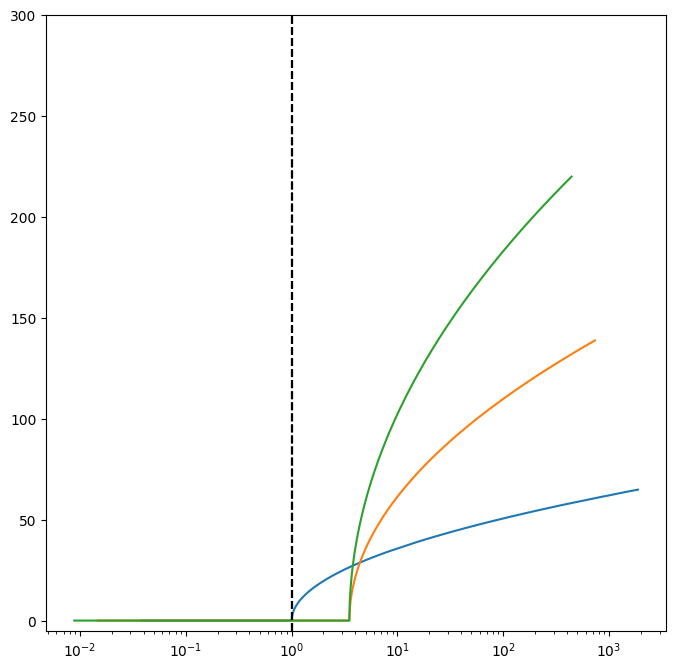

In [80]:
rr = np.arange(12, 17, 1)
atom_N = [13,20,32,50,79]
total_N_c = np.outer(10**rr, atom_N) / 10
total_N_c = total_N_c.flatten()



rand_nn = [11.8 , 30 , 50]
color = ['r','b','g']

fig = plt.figure(1,figsize=(8,8))

# plt.subplot(211)

shape= np.array(['o','D','s'])

for kk , rand in enumerate(rand_nn):

    vv = []
    opt = np.array([])
    for ii, index in enumerate(rr):
        for jj , atom in enumerate(atom_N):
            a , lam = del_v_peaks('k',atom,index,0,1,rand)
            vv.append(a)
            nciv = (atom/10)*10**index
            bb = tau_0('k',nciv,rand)
            opt = np.append(opt,bb)

    V_del_peak, nu_esc, N_esc_anl = N_esc_scat(rand)

    # tau_cal = (total_N_c /(2.67e13))*(11.8/rand)
    # plt.plot(tau_cal,Del_V ,linestyle='--',alpha=0.5,color = color[kk],lw=4)
    # print(opt)

    C_iv_N = np.logspace(np.log10(1e12), np.log10(5e16), int(NN))
    tauo_analytic =tau_0('k',C_iv_N,rand)
    plt.plot(tauo_analytic,V_del_peak)
    # plt.plot(opt, vv,marker=shape[kk],linestyle='',markersize=12,alpha=0.7,color = color[kk],label = r'${}$'.format(rand))
    plt.xscale('log')
    plt.ylim(-5,300)

    plt.axvline(x=1,ymin=0,ymax=1,linestyle='--',color='k')

In [114]:


    # # 벡터화된 tau 및 Voigt 프로파일 계산
    # Voigt_profile = Voigt(xx,v_th,K_gamma, C_IV_K)
    # tau_profile = tau_0('k',C_iv_N[:, None],v_th) * Voigt_profile
    # tau_0(Line, atom_num, atom_index, vout, vemit, vran)


    # x_0 계산
    # x_0 = np.zeros(len(C_iv_N))
    # for ii, jj in enumerate(C_iv_N):
    #     x_p = np.where(np.diff(np.sign(1 - tau_profile[ii, :])))[0]
    #     x_0[ii] = xx[x_p].max() if x_p.size > 0 else 0

    # del_lam_D = v_th / C_IV_K
    # nu_0_K= cc/C_IV_K
    # nu_esc = x_0*del_lam_D + nu_0_K
    # V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    # v_esc = x_0*v_th
    # N_esc= 1/special.erfc(v_esc/v_th)

    # return C_iv_N, N_esc , V_del_peak

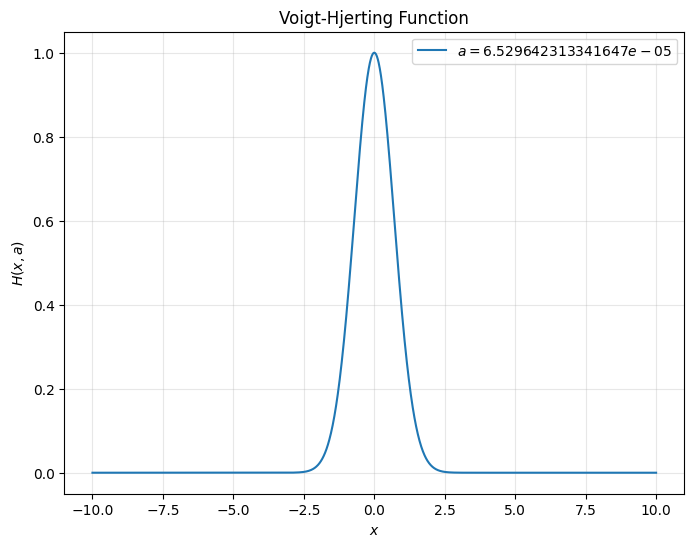

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import wofz

def H_voigt_fast(x, a):
    z = x + 1j*a
    return np.real(wofz(z))

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s

x_arr = np.linspace(-10, 10, 2000)
# a_values = [1e-3, 1e-2, 1e-1, 1.0]

gamma_K= 2.65e8 # 1/ s 
Delnu = (50/cc_k) * 1.936410e15

a = gamma_K / (4*np.pi*Delnu)

plt.figure(figsize=(8, 6))
# for a in a_values:
plt.plot(x_arr, H_voigt_fast(x_arr, a), label=fr"$a={a}$")

plt.xlabel(r"$x$")
plt.ylabel(r"$H(x,a)$")
plt.title("Voigt-Hjerting Function")
plt.legend()
plt.grid(alpha=0.3)
plt.show()